In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import (accuracy_score, f1_score,
                             mean_absolute_error, r2_score)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

In [2]:
with open("splits_scaled.pkl", "rb") as f:
    splits = pickle.load(f)

TASKS = {
    "Type_Of_Failure" : "classification",
    "Serial_Device"   : "classification",
    "Down_Time"       : "regression",
    "When_Panne"      : "regression",
}

results = {}


  TÂCHE : Type_Of_Failure  (classification)


C:\Users\Dell\anaconda3\envs\pfe\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



  📊 Cross-Validation (5 folds) :
     Scores  : [0.4623 0.4304 0.2192 0.4684 0.439 ]
     Moyenne : 0.4038  ±  0.0934

  🩺 DIAGNOSTIC :
     Accuracy    : 0.4903  → 🔴 Faible
     F1-weighted : 0.4740   → 🔴 Faible


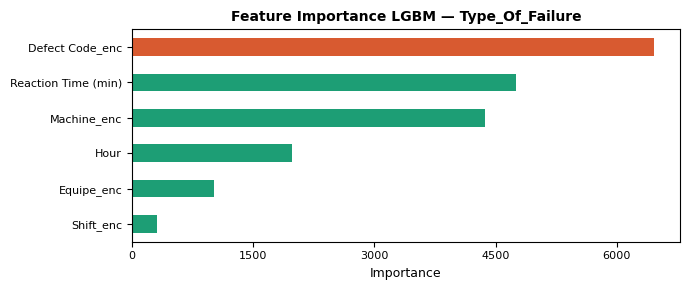

  💾 Sauvegardé → lgbm_type_of_failure.pkl

  TÂCHE : Serial_Device  (classification)


C:\Users\Dell\anaconda3\envs\pfe\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



  📊 Cross-Validation (5 folds) :
     Scores  : [0.0624 0.088  0.0838 0.1302 0.1383]
     Moyenne : 0.1006  ±  0.0290

  🩺 DIAGNOSTIC :
     Accuracy    : 0.1059  → 🔴 Faible
     F1-weighted : 0.1435   → 🔴 Faible


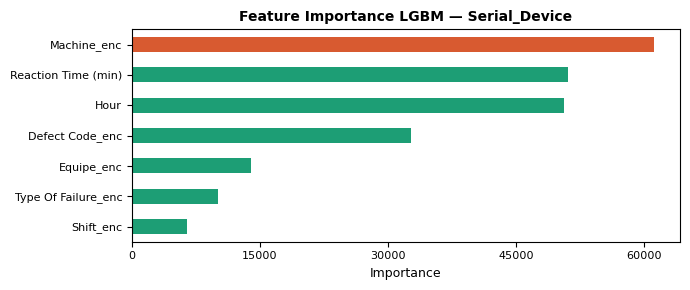

  💾 Sauvegardé → lgbm_serial_device.pkl

  TÂCHE : Down_Time  (regression)

  📊 Cross-Validation (5 folds) :
     Scores  : [5.2936 5.7157 5.5533 5.1445 5.4576]
     Moyenne : 5.4329  ±  0.1988

  🩺 DIAGNOSTIC :
     MAE  : 5.3214  → 🟡 Bon (< 10 min)
     R²   : 0.0735   → 🔴 Faible


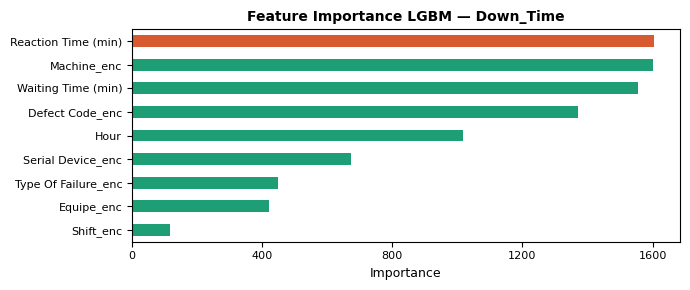

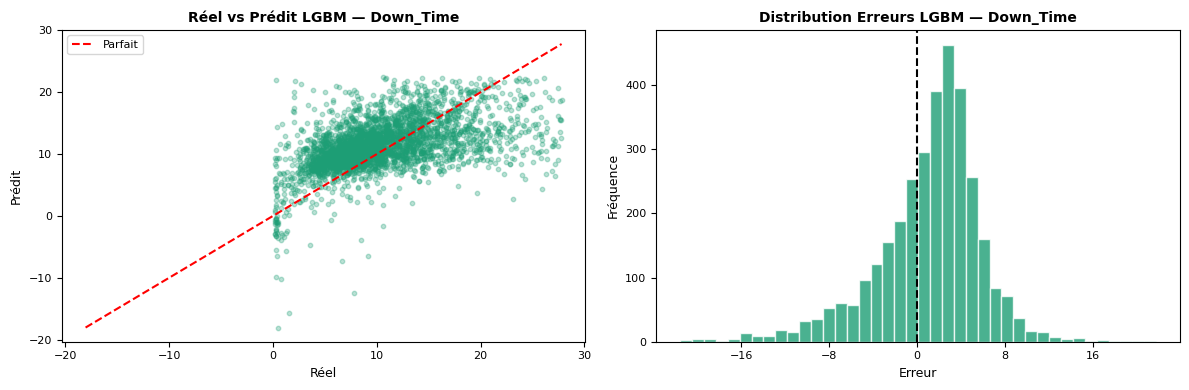

  💾 Sauvegardé → lgbm_down_time.pkl

  TÂCHE : When_Panne  (regression)

  📊 Cross-Validation (5 folds) :
     Scores  : [28.9411 31.6812 28.2296 30.8904 30.9811]
     Moyenne : 30.1447  ±  1.3216

  🩺 DIAGNOSTIC :
     MAE  : 29.8630  → 🟠 Moyen
     R²   : -0.2059   → 🔴 Faible


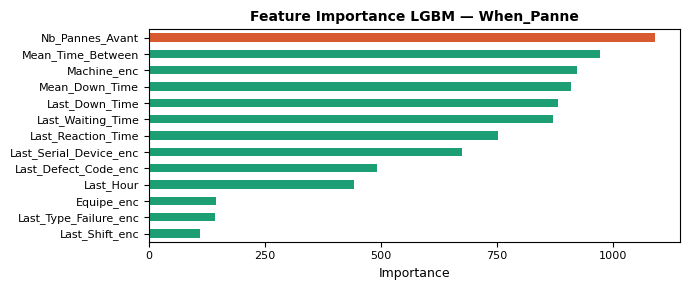

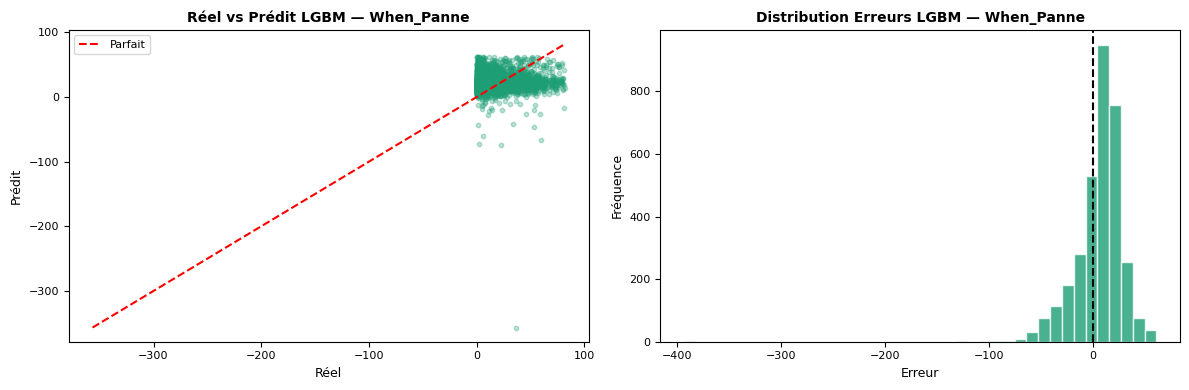

  💾 Sauvegardé → lgbm_when_panne.pkl

  📋 RÉCAPITULATIF — LIGHTGBM
                    model  cv_mean accuracy      f1     mae      r2
Type_Of_Failure  LightGBM   0.4038   0.4903   0.474       -       -
Serial_Device    LightGBM   0.1006   0.1059  0.1435       -       -
Down_Time        LightGBM   5.4329        -       -  5.3214  0.0735
When_Panne       LightGBM  30.1447        -       -  29.863 -0.2059
✅ results_lightgbm.csv sauvegardé


In [3]:
def diagnostic(score, metric):
    if metric == "accuracy":
        if score >= 0.95: return "🟢 Excellent"
        if score >= 0.80: return "🟡 Bon"
        if score >= 0.60: return "🟠 Moyen"
        return "🔴 Faible"
    elif metric == "f1":
        if score >= 0.90: return "🟢 Excellent"
        if score >= 0.70: return "🟡 Bon"
        if score >= 0.50: return "🟠 Moyen"
        return "🔴 Faible"
    elif metric == "mae_down":
        if score <= 5:  return "🟢 Excellent (< 5 min)"
        if score <= 10: return "🟡 Bon (< 10 min)"
        if score <= 20: return "🟠 Moyen"
        return "🔴 Faible"
    elif metric == "mae_when":
        if score <= 10: return "🟢 Excellent (< 10h)"
        if score <= 20: return "🟡 Bon (< 20h)"
        if score <= 35: return "🟠 Moyen"
        return "🔴 Faible"
    elif metric == "r2":
        if score >= 0.80: return "🟢 Excellent"
        if score >= 0.50: return "🟡 Bon"
        if score >= 0.20: return "🟠 Moyen"
        return "🔴 Faible"

for task, mode in TASKS.items():

    print(f"\n{'='*60}")
    print(f"  TÂCHE : {task}  ({mode})")
    print(f"{'='*60}")

    s     = splits[task]
    Xtr   = s["Xtr_scaled"].copy()
    Xte   = s["Xte_scaled"].copy()
    ytr   = s["ytr"].copy()
    yte   = s["yte"].copy()
    feats = list(s["feats"])

    if mode == "classification":
        le  = LabelEncoder()
        ytr = le.fit_transform(ytr)
        yte = le.transform(yte)

        model = LGBMClassifier(
            n_estimators    = 300,
            max_depth       = 6,
            learning_rate   = 0.1,
            subsample       = 0.8,
            colsample_bytree= 0.8,
            min_child_samples= 5,   # gère les classes rares
            n_jobs          = -1,
            random_state    = 42,
            verbose         = -1    # silence les logs
        )
        cv_metric = "f1_weighted"
    else:
        model = LGBMRegressor(
            n_estimators    = 300,
            max_depth       = 6,
            learning_rate   = 0.1,
            subsample       = 0.8,
            colsample_bytree= 0.8,
            min_child_samples= 5,
            n_jobs          = -1,
            random_state    = 42,
            verbose         = -1
        )
        cv_metric = "neg_mean_absolute_error"

    # ── Cross-Validation ─────────────────────────────────────
    cv_scores = cross_val_score(model, Xtr, ytr,
                                cv=5, scoring=cv_metric, n_jobs=-1)
    if mode == "regression":
        cv_scores = -cv_scores

    print(f"\n  📊 Cross-Validation (5 folds) :")
    print(f"     Scores  : {np.round(cv_scores, 4)}")
    print(f"     Moyenne : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")

    # ── Entraînement ─────────────────────────────────────────
    model.fit(Xtr, ytr)
    ypred = model.predict(Xte)

    # ── Diagnostic ───────────────────────────────────────────
    print(f"\n  🩺 DIAGNOSTIC :")
    if mode == "classification":
        acc = accuracy_score(yte, ypred)
        f1  = f1_score(yte, ypred, average="weighted", zero_division=0)
        print(f"     Accuracy    : {acc:.4f}  → {diagnostic(acc, 'accuracy')}")
        print(f"     F1-weighted : {f1:.4f}   → {diagnostic(f1, 'f1')}")
        results[task] = {"model": "LightGBM", "cv_mean": round(cv_scores.mean(),4),
                         "accuracy": round(acc,4), "f1": round(f1,4),
                         "mae": "-", "r2": "-"}
    else:
        mae = mean_absolute_error(yte, ypred)
        r2  = r2_score(yte, ypred)
        m   = "mae_down" if task == "Down_Time" else "mae_when"
        print(f"     MAE  : {mae:.4f}  → {diagnostic(mae, m)}")
        print(f"     R²   : {r2:.4f}   → {diagnostic(r2, 'r2')}")
        results[task] = {"model": "LightGBM", "cv_mean": round(cv_scores.mean(),4),
                         "accuracy": "-", "f1": "-",
                         "mae": round(mae,4), "r2": round(r2,4)}

    # ── Feature Importance ───────────────────────────────────
    fi = pd.Series(model.feature_importances_, index=feats)\
           .sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(7, 3))
    colors = ["#D85A30" if v == fi.max() else "#1D9E75" for v in fi]
    fi.plot(kind="barh", ax=ax, color=colors)
    ax.set_xlabel("Importance", fontsize=9)
    ax.set_title(f"Feature Importance LGBM — {task}", fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=8)
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    plt.tight_layout()
    plt.savefig(f"fi_lgbm_{task.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

    if mode == "regression":
        mask    = (yte < np.percentile(yte, 95)) & (ypred < np.percentile(ypred, 95))
        yte_p   = yte[mask]
        ypred_p = ypred[mask]
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].scatter(yte_p, ypred_p, alpha=0.3, s=10, color="#1D9E75")
        lmin = min(yte_p.min(), ypred_p.min())
        lmax = max(yte_p.max(), ypred_p.max())
        axes[0].plot([lmin,lmax],[lmin,lmax],'r--',lw=1.5,label="Parfait")
        axes[0].set_xlabel("Réel", fontsize=9)
        axes[0].set_ylabel("Prédit", fontsize=9)
        axes[0].set_title(f"Réel vs Prédit LGBM — {task}", fontsize=10, fontweight="bold")
        axes[0].tick_params(labelsize=8)
        axes[0].xaxis.set_major_locator(plt.MaxNLocator(6))
        axes[0].yaxis.set_major_locator(plt.MaxNLocator(6))
        axes[0].legend(fontsize=8)
        errors = ypred_p - yte_p
        axes[1].hist(errors, bins=40, color="#1D9E75", edgecolor="white", alpha=0.8)
        axes[1].axvline(0, color="black", lw=1.5, linestyle="--")
        axes[1].set_xlabel("Erreur", fontsize=9)
        axes[1].set_ylabel("Fréquence", fontsize=9)
        axes[1].set_title(f"Distribution Erreurs LGBM — {task}", fontsize=10, fontweight="bold")
        axes[1].tick_params(labelsize=8)
        axes[1].xaxis.set_major_locator(plt.MaxNLocator(6))
        plt.tight_layout()
        plt.savefig(f"reg_lgbm_{task.lower()}.png", dpi=150, bbox_inches="tight")
        plt.show()

    fname = f"lgbm_{task.lower()}.pkl"
    with open(fname, "wb") as f:
        pickle.dump(model, f)
    print(f"  💾 Sauvegardé → {fname}")

print(f"\n{'='*60}")
print("  📋 RÉCAPITULATIF — LIGHTGBM")
print(f"{'='*60}")
df_res = pd.DataFrame(results).T
print(df_res.to_string())
df_res.to_csv("results_lightgbm.csv")
print("✅ results_lightgbm.csv sauvegardé")